In [176]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/karishmas24/master-traing-data/master_training_data.csv


In [177]:
import tensorflow as tf
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, precision_recall_curve
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping



from sklearn.metrics import confusion_matrix
import seaborn as sns

In [178]:
file_path='/kaggle/input/datasets/karishmas24/master-traing-data/master_training_data.csv'
print('data loading')
df=pd.read_csv(file_path)

data loading


In [179]:
print(f"data successfully loaded':{df.shape[0]},total Columns:{df.shape[1]}")


data successfully loaded':8914963,total Columns:38


In [180]:
print("DATA TYPES CHECK")
text_cols = df.select_dtypes(include=['object']).columns
if len(text_cols) > 0:
    print(f"Alert! all text are not changed (Model fail ho sakta hai): {list(text_cols)}")
else:
    print(" Perfect! complete data is converted into Numbers")


print("MISSING VALUES CHECK:")
missing_data = df.isnull().sum()
missing_cols = missing_data[missing_data > 0]
if len(missing_cols) > 0:
    print("Alert! In columns me blank space hai:")
    print(missing_cols)
else:
    print(" Perfect!No blank space")


print(" FRAUD RATIO CHECK:")
fraud_counts = df['is_fraud'].value_counts()
print(f"Safe Transactions (0): {fraud_counts[0]}")
print(f"Fraud Transactions (1): {fraud_counts[1]}")

DATA TYPES CHECK
 Perfect! complete data is converted into Numbers
MISSING VALUES CHECK:
 Perfect!No blank space
 FRAUD RATIO CHECK:
Safe Transactions (0): 8901631
Fraud Transactions (1): 13332


In [181]:
#X----question
#Y----answer
print('data splitting phase')
Y=df['is_fraud']
X=df.drop(columns=['is_fraud','id'])
print('train the data')
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

print('splitting completed!')
print(f"training Data Size:{X_train.shape}")
print(f"testing data size:{X_test.shape}")

data splitting phase
train the data
splitting completed!
training Data Size:(7131970, 36)
testing data size:(1782993, 36)


In [182]:
print("\n--- STARTING STAGE 1: XGBOOST ---")

fraud_weight=len(Y_train[Y_train==0])/len(Y_train[Y_train==1])*2
model=xgb.XGBClassifier(
    n_estimators=200,
    max_depth=8,
    scale_pos_weight=fraud_weight,
    random_state=42,
    n_jobs=-1,
    device="cuda"
)


--- STARTING STAGE 1: XGBOOST ---


In [183]:
print('Training XGBoost model on GPU...')
model.fit(X_train,Y_train)
print('traing complete')

Training XGBoost model on GPU...
traing complete


In [184]:
print('store the data Y_test')
Y_pred=model.predict(X_test)

print('now we are checking accuracy')
accuracy=accuracy_score(Y_test,Y_pred)
print(f"XGBoost Model Accuracy: {accuracy * 100:.2f}%\n")

print("Detained Classification Report:")
print(classification_report(Y_test,Y_pred))



store the data Y_test
now we are checking accuracy
XGBoost Model Accuracy: 99.91%

Detained Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1780357
           1       0.65      0.88      0.75      2636

    accuracy                           1.00   1782993
   macro avg       0.82      0.94      0.87   1782993
weighted avg       1.00      1.00      1.00   1782993



In [185]:
probs=model.predict_proba(X_test)[:,1]


precisions,recalls,thresholds=precision_recall_curve(Y_test,probs)
# safe_limit=thresholds[np.where(recalls>=0.99)[0][-1]]

s1_safe_idx = np.where(recalls >= 0.999)[0]
safe_limit = thresholds[s1_safe_idx[-1]] if len(s1_safe_idx) > 0 else 0.02
print(f"AI decided safe limit(threshold): {safe_limit:.4f}")


test_results=pd.DataFrame()
##pd.DataFrame(): Pandas library (pd) ko bola ki ek nayi, khali Excel jaisi table bana do.
test_results['Actual Answer']=Y_test.values
test_results['AI_fraud_chance_%']=probs*100

print('putting condition')
conditions=[
    (test_results['AI_fraud_chance_%']<(safe_limit*100)),
    (test_results['AI_fraud_chance_%']>=(safe_limit*100))
]
choice=['direct pass(safe)','send to stage 2 (doubt)']

test_results['decision']=np.select(conditions,choice,default='Unknown')

print(test_results['decision'].value_counts())

AI decided safe limit(threshold): 0.0000
putting condition
decision
direct pass(safe)          1227011
send to stage 2 (doubt)     555982
Name: count, dtype: int64


In [186]:
#stage 2:LSTM(Long Short-Term Memory)
print('\n--- STARTING STAGE 2: LSTM ---')


--- STARTING STAGE 2: LSTM ---


In [187]:


mask = test_results['decision'] == 'send to stage 2 (doubt)'
X_s2 = X_test[mask.values]
Y_s2 = Y_test[mask.values] 

print(f"Total doubtful transactions found: {len(X_s2)}")

LOOKBACK=5
if len(X_s2) > LOOKBACK:
    # Function to create Time Series Sequences
    def create_seq(X_data, Y_data, lookback=5):
        X_seq, Y_seq = [], []
        for i in range(len(X_data) - lookback):
            X_seq.append(X_data.iloc[i:i+lookback].values)
            Y_seq.append(Y_data.iloc[i+lookback]) 
        return np.array(X_seq), np.array(Y_seq)

    
    # # Scale the features
    scaler = StandardScaler()
    X_s2_scaled = pd.DataFrame(scaler.fit_transform(X_s2), columns=X_s2.columns)

    # Create Sequences
    X_s2_seq, Y_s2_seq = create_seq(X_s2_scaled, Y_s2, lookback=LOOKBACK)
    print(f"Data converted into sequence! Shape: {X_s2_seq.shape}")

    # Define LSTM Architecture
    model_lstm = Sequential([
        Input(shape=(LOOKBACK, X_s2.shape[1])),
        LSTM(128, return_sequences=True, activation='tanh'),
        BatchNormalization(),
        Dropout(0.3),
        LSTM(64, return_sequences=False, activation='tanh'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
    model_lstm.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['AUC'])


    # Dynamic Class Weights
    weights = compute_class_weight('balanced', classes=np.unique(Y_s2_seq), y=Y_s2_seq)
    class_weights = {0: weights[0], 1: weights[1]}

    # Early Stopping
    early_stop = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)

    # Train Model
    print("Training LSTM model...")
    model_lstm.fit(X_s2_seq, Y_s2_seq, epochs=50, batch_size=2048, 
                   class_weight=class_weights, callbacks=[early_stop], verbose=1)

    

    # Predict & Threshold
    lstm_probs = model_lstm.predict(X_s2_seq).flatten()
    s2_precisions, s2_recalls, s2_thresholds = precision_recall_curve(Y_s2_seq, lstm_probs)

    recall_target = 0.85
    idx = np.where(s2_recalls >= recall_target)[0]

    if len(idx) > 0:
         s2_threshold = s2_thresholds[idx[-1]]
    else:
         s2_threshold = 0.40 # Agar recall target nahi mila toh 0.3 par block karein

    print(f"Stage 2 Threshold identified: {s2_threshold:.4f}")
    
    # # Target 85% Precision
    # try:
    #     s2_threshold = s2_thresholds[np.where(s2_precisions >= 0.85)[0][0]]
    # except IndexError:
    #     s2_threshold = 0.5 # Fallback if 85% isn't reached


    # print(f"Stage 2 Threshold identified: {s2_threshold:.4f}")


    # f1_scores = 2 * (s2_precisions * s2_recalls) / (s2_precisions + s2_recalls + 1e-10)
    # best_idx = np.argmax(f1_scores)
    # s2_threshold = s2_thresholds[best_idx]
    # print(f"Stage 2 Optimized Threshold (F1-based): {s2_threshold:.4f}")
    
    # Update Final Decisions
    valid_indices = mask[mask].index[LOOKBACK:]
    test_results.loc[valid_indices, 'decision'] = np.where(
        lstm_probs >= s2_threshold, 'Confirmed Fraud', 'Cleaned'
    )
    print("Stage 2 processing complete.")
else:
    print("Alert: Not enough doubtful transactions to train LSTM. Skipping Stage 2.")



Total doubtful transactions found: 555982
Data converted into sequence! Shape: (555977, 5, 36)
Training LSTM model...
Epoch 1/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - AUC: 0.4983 - loss: 0.7686
Epoch 2/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - AUC: 0.5414 - loss: 0.7103
Epoch 3/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - AUC: 0.5597 - loss: 0.6969
Epoch 4/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - AUC: 0.5763 - loss: 0.6890
Epoch 5/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - AUC: 0.6086 - loss: 0.6754
Epoch 6/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - AUC: 0.6117 - loss: 0.6738
Epoch 7/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - AUC: 0.6273 - loss: 0.6679
Epoch 8/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - AUC: 0.6448 - loss: 0.6587
Epoch 9/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - AUC: 0.6632 - loss: 0.6509
Epoch 10/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - AUC: 0.6699 - loss: 0.6462
Epoch 11/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - AUC: 

     FINAL SYSTEM PERFORMANCE REPORT      
decision
direct pass(safe)          1227011
Cleaned                     549124
Confirmed Fraud               6853
send to stage 2 (doubt)          5
Name: count, dtype: int64


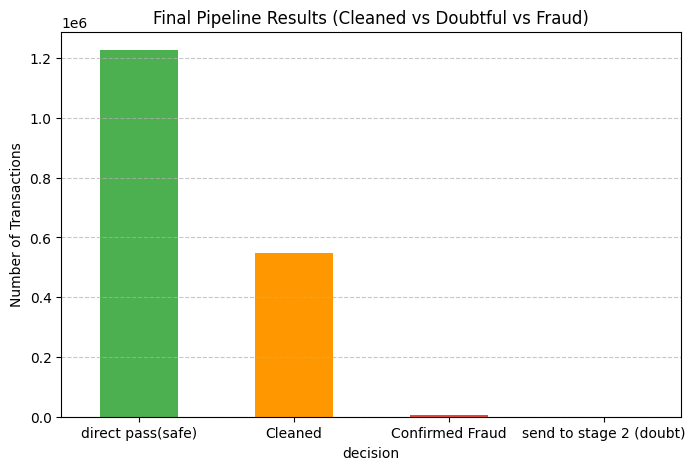

In [188]:
print("     FINAL SYSTEM PERFORMANCE REPORT      ")
summary = test_results['decision'].value_counts()
print(summary)


# Visualizing the final results
plt.figure(figsize=(8, 5))
summary.plot(kind='bar', color=['#4CAF50', '#FF9800', '#F44336'])
plt.title('Final Pipeline Results (Cleaned vs Doubtful vs Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

y_true type: int64, y_pred type: int64

--- DETAILED PERFORMANCE METRICS ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1780357
           1       0.33      0.85      0.47      2636

    accuracy                           1.00   1782993
   macro avg       0.66      0.92      0.74   1782993
weighted avg       1.00      1.00      1.00   1782993



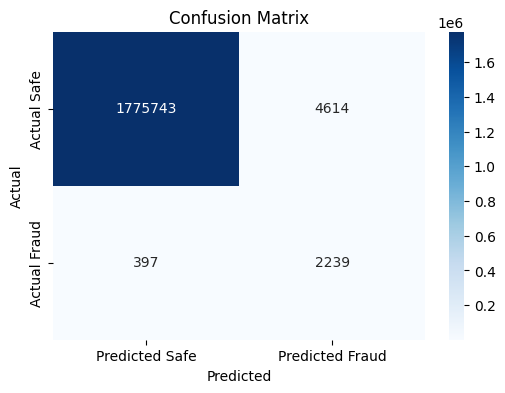

In [189]:
mapping = {'Confirmed Fraud': 1, 'Cleaned': 0, 'direct pass(safe)': 0}

y_true = test_results['Actual Answer'].astype(int)
y_pred = test_results['decision'].map(mapping).fillna(0).astype(int)

# 2. Check ki dono ka type sahi hai
print(f"y_true type: {y_true.dtype}, y_pred type: {y_pred.dtype}")

# 3. Detailed Report
print("\n--- DETAILED PERFORMANCE METRICS ---")
print(classification_report(y_true, y_pred))

# 4. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Safe', 'Predicted Fraud'],
            yticklabels=['Actual Safe', 'Actual Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

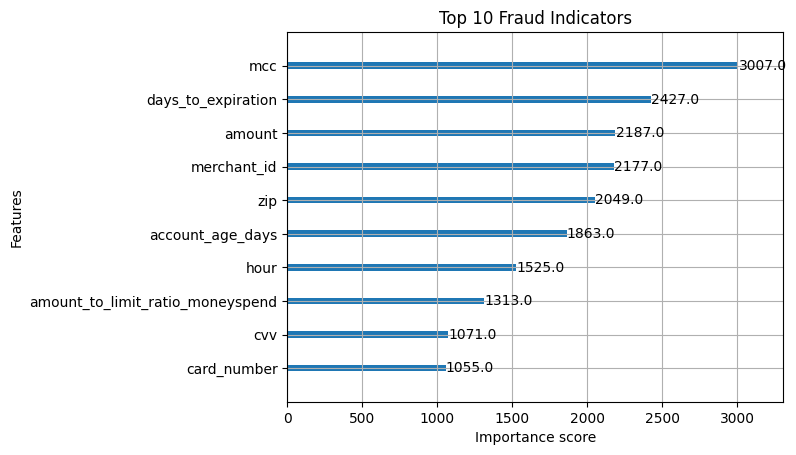

In [190]:
# XGBoost Stage 1 ki importance dekhne ke liye:
xgb.plot_importance(model, max_num_features=10)
plt.title("Top 10 Fraud Indicators")
plt.show()

In [191]:
# 1. Sabse pehle 'bias_check' dataframe banayein
if 'zip' in X_test.columns:
    bias_check = test_results.copy()
    bias_check['zip'] = X_test['zip'].values 
    
    # 2. Phir 'groupby' karein
    region_stats = bias_check.groupby('zip').agg(
        total_transactions=('decision', 'count'),
        fraud_predictions=('decision', lambda x: (x == 'Confirmed Fraud').sum())
    )

    # 3. Fraud rate calculate karein
    region_stats['fraud_rate'] = region_stats['fraud_predictions'] / region_stats['total_transactions']

    # 4. Significant data filter lagayein
    significant_regions = region_stats[region_stats['total_transactions'] >= 50]

    # 5. Output print karein
    print("Top 10 regions with highest fraud rate (Significant Data):")
    print(significant_regions.sort_values(by='fraud_rate', ascending=False).head(10))

else:
    print("Error: 'zip' column X_test mein nahi mila. Check karein ki dataset mein column ka naam kya hai.")

Top 10 regions with highest fraud rate (Significant Data):
         total_transactions  fraud_predictions  fraud_rate
zip                                                       
44680.0                 119                 37    0.310924
35046.0                  76                  3    0.039474
11722.0                  51                  2    0.039216
12936.0                  53                  2    0.037736
74146.0                  55                  2    0.036364
95663.0                  55                  2    0.036364
92230.0                  57                  2    0.035088
49651.0                  58                  2    0.034483
62526.0                  60                  2    0.033333
53549.0                  61                  2    0.032787


In [192]:
# 1. Zip code filter (Indices ka use karein taaki original data access kar sakein)
target_indices = bias_check[bias_check['zip'] == 44680.0].index

# 2. Original data se amount aur merchant_id fetch karein
high_risk_details = df.loc[target_indices].copy()
high_risk_details['decision'] = bias_check.loc[target_indices, 'decision']

# 3. Average Amount Check
print("Average Amount of Fraud vs Safe:")
# Column name 'amount' verify kar lein, agar kuch aur hai toh yahan change karein
print(high_risk_details.groupby('decision')['amount'].mean())

# 4. Merchant ID Check
print("\nFraudulent Merchant IDs in this region:")
fraud_only = high_risk_details[high_risk_details['decision'] == 'Confirmed Fraud']

if 'merchant_id' in fraud_only.columns:
    print(fraud_only['merchant_id'].value_counts())
else:
    print("Column 'merchant_id' not found in original dataframe.")

Average Amount of Fraud vs Safe:
decision
Cleaned              31.407400
Confirmed Fraud      46.467027
direct pass(safe)    21.640313
Name: amount, dtype: float64

Fraudulent Merchant IDs in this region:
merchant_id
39021    3
14528    3
27092    3
73186    2
43293    2
59935    2
75781    2
61195    1
92208    1
13646    1
25887    1
98374    1
20519    1
26810    1
81833    1
6473     1
92290    1
59697    1
49637    1
79664    1
6063     1
30928    1
31785    1
94412    1
85986    1
46284    1
71063    1
Name: count, dtype: int64


In [193]:
# --- ADD THIS: SYSTEM PERFORMANCE EVALUATION REPORT ---
import time

def evaluate_system_health(X_test, Y_test, stage1_model, model_lstm, scaler, s1_threshold, s2_threshold, LOOKBACK):
    print("\n==================================================")
    print("         SYSTEM LEVEL ROUTING BREAKDOWN           ")
    print("==================================================")
    
    start_time = time.time()
    
    # 1. Stage 1 Predictions
    s1_probs = stage1_model.predict_proba(X_test)[:, 1]
    
    # 2. Stage 2 Filter Logic
    doubtful_mask = (s1_probs >= s1_threshold)
    X_s2_subset = X_test[doubtful_mask]
    
    # Sequence logic for evaluation (Sif doubtful cases ke liye)
    s2_count = 0
    if len(X_s2_subset) >= LOOKBACK:
        X_s2_scaled = scaler.transform(X_s2_subset)
        X_s2_seq = np.array([X_s2_scaled[i:i+LOOKBACK] for i in range(len(X_s2_scaled)-LOOKBACK+1)])
        lstm_probs = model_lstm.predict(X_s2_seq).flatten()
        s2_count = np.sum(lstm_probs >= s2_threshold)
        
    end_time = time.time()
    
    # 3. Metrics Calculation
    total_tx = len(X_test)
    approved = np.sum(s1_probs < s1_threshold)
    dashboard = total_tx - approved - s2_count
    
    print(f"Total Traffic Processed     : {total_tx}")
    print(f"Stage 1 Auto-Approved       : {approved} ({approved/total_tx*100:.2f}%)")
    print(f"Stage 2 Auto-Rejected       : {s2_count} ({s2_count/total_tx*100:.4f}%)")
    print(f"Routed to Dashboard         : {dashboard} ({dashboard/total_tx*100:.2f}%)")
    print(f"Total System Automation Rate: {(approved+s2_count)/total_tx*100:.2f}%")
    print(f"Total Processing Throughput : {total_tx / (end_time - start_time + 0.001):.2f} tx/sec")
    print("==================================================")


evaluate_system_health(X_test, Y_test, model, model_lstm, scaler, safe_limit, s2_threshold, LOOKBACK)


         SYSTEM LEVEL ROUTING BREAKDOWN           
17375/17375 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step
Total Traffic Processed     : 1782993
Stage 1 Auto-Approved       : 1227011 (68.82%)
Stage 2 Auto-Rejected       : 6853 (0.3844%)
Routed to Dashboard         : 549129 (30.80%)
Total System Automation Rate: 69.20%
Total Processing Throughput : 38540.50 tx/sec


In [194]:
import joblib

# 1. XGBoost save
model.save_model("stage1_xgb.json")

# 2. LSTM save
model_lstm.save("stage2_lstm.keras")

# 3. Scaler save
joblib.dump(scaler, "scaler.pkl")

print("Pipeline Saved! Files: stage1_xgb.json, stage2_lstm.keras, scaler.pkl")

Pipeline Saved! Files: stage1_xgb.json, stage2_lstm.keras, scaler.pkl


In [195]:
from IPython.display import FileLink

# Har file ke liye download link generate karein
display(FileLink('stage1_xgb.json'))
display(FileLink('stage2_lstm.keras'))
display(FileLink('scaler.pkl'))

/kaggle/working/stage1_xgb.json

/kaggle/working/stage2_lstm.keras

/kaggle/working/scaler.pkl